In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True



In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /home/mine/10 Academy/news-sentiment-analysis


In [3]:
# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls
from src.analysis    import compute_sma, get_daily_return

print('Functions imported successfully!')
print()

Functions imported successfully!



In [13]:
aapl_df = load_data('../Data/yfinance_data/AAPL.csv')
aapl_df.head()

ts = aapl_df[['Close']].rename(columns={'Close': 'Sales'})
ts.index.name = "Date"
ts.dropna(inplace=True)

ts_filled = ts.copy() 

ts.head()


Loaded 3774 rows from ../Data/yfinance_data/AAPL.csv


,Sales
Date,
2009-01-02,2.721686
2009-01-05,2.836553
2009-01-06,2.789767
2009-01-07,2.729484
2009-01-08,2.780169


In [5]:
print('Missing values per column AAPL:')
print(aapl_df.isnull().sum())
print()

# Now remove them — one line instead of five
aapl_df = remove_nulls(aapl_df)

Missing values per column AAPL:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


--- Summary Statistics ---
             Sales      Returns
count  3774.000000  3773.000000
mean     53.841169     0.001289
std      55.064042     0.018010
min       2.345299    -0.128647
25%      15.050355    -0.007547
50%      26.975808     0.001062
75%      74.664204     0.010770
max     196.256592     0.119808


/tmp/ipykernel_8327/4203261430.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts_filled['Sales'].resample('M').sum()


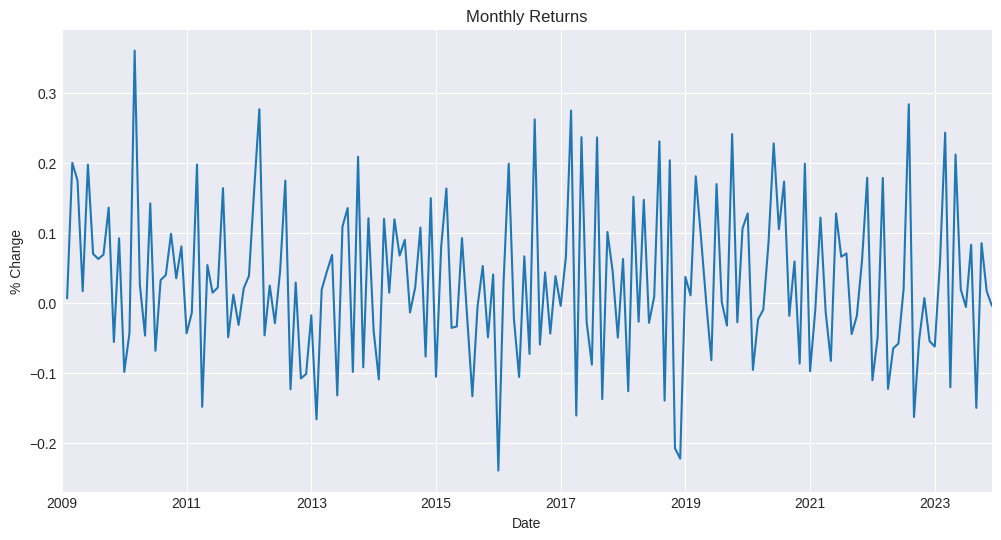

In [17]:
# Summary Statistics
print("--- Summary Statistics ---")
print(ts_filled.describe())

# Calculate Monthly Returns (Percentage Change)
monthly_sales = ts_filled['Sales'].resample('M').sum()

monthly_returns = monthly_sales.pct_change()

plt.figure(figsize=(12,6))
monthly_returns.plot(title="Monthly Returns")
plt.ylabel("% Change")
plt.show()

In [18]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   3774 non-null   float64
dtypes: float64(1)
memory usage: 59.0 KB


/tmp/ipykernel_8327/3896099303.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts["Sales"].resample('M').sum().plot()


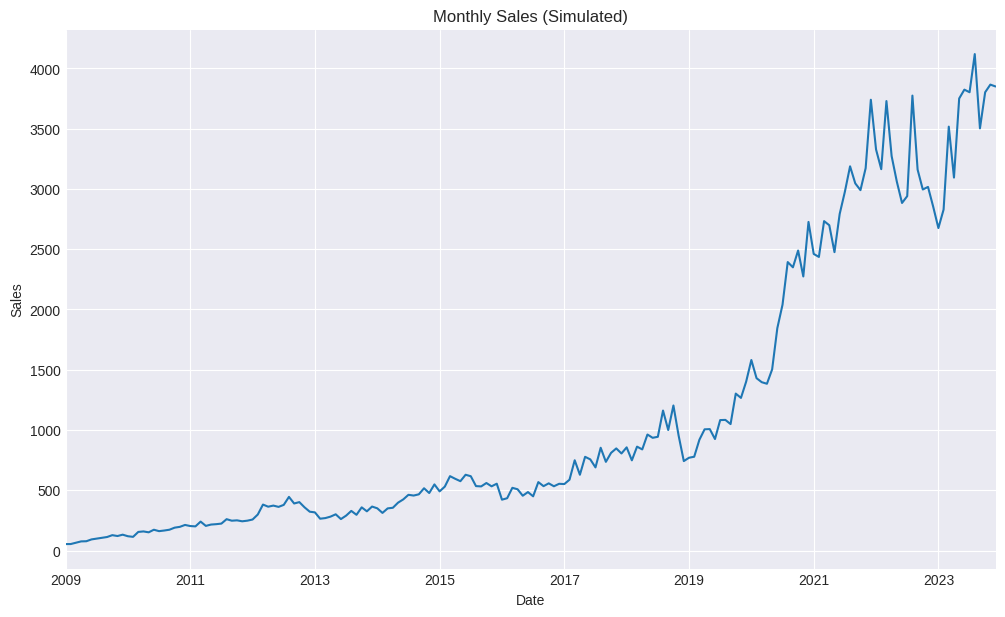

In [19]:

ts["Sales"].resample('M').sum().plot()
plt.title("Monthly Sales (Simulated)")
plt.ylabel("Sales")
plt.show()

Interpretation of Monthly Sales Trend

From 2009 to end 2016, the price is relatively flat (a "sideways" trend).
Starting in early-2017, The price isn't just a straight line; it has peaks and valleys. 
Starting in early-2019, you see a massive Upward Trend. In quantitative terms, this is where the "Momentum" shifted significantly.By looking at this, you can see that Apple doesn't just go up—it goes up with very sharp pullbacks (the "zig-zags"). 



/tmp/ipykernel_8327/4136306247.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  result = seasonal_decompose(ts["Sales"].resample('M').sum(), model="additive", period=12)  # period=12 months


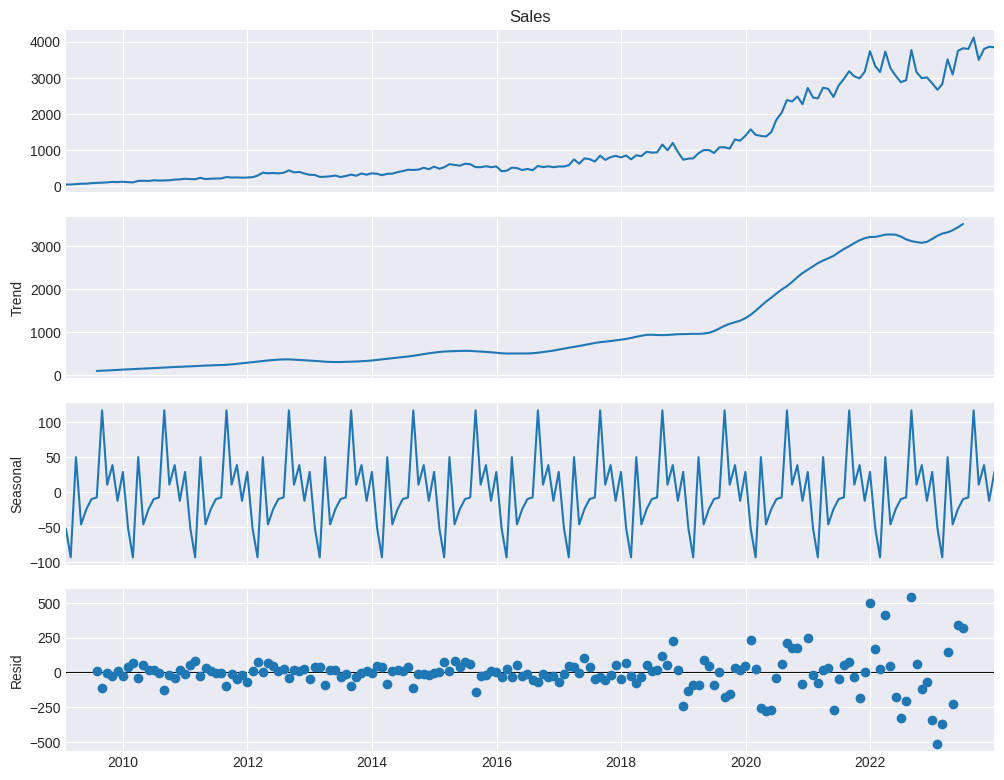

In [22]:
# Decompose the series into components

result = seasonal_decompose(ts["Sales"].resample('M').sum(), model="additive", period=12)  # period=12 months

fig = result.plot()
fig.set_size_inches(10, 8)
plt.show()


Time Series Decomposition Interpretation

The decomposition breaks the Sales series into four components—Observed, Trend, Seasonal, and Residual—revealing how different patterns contribute to overall behavior:

1. Observed (Top Plot)

The original sales data shows a steady upward movement from 2009 to 2022, with visible short-term fluctuations.

2. Trend (Second Plot)

The trend component captures the long-term direction.
It shows a consistent and smooth increase, indicating that sales are growing steadily over the 5-year period.

3. Seasonal (Third Plot)

The seasonal component repeats every 12 months, showing regular annual patterns.
Sales are higher during certain months and lower during others, confirming a stable, repeating seasonal cycle.

4. Residual (Bottom Plot)

The residuals represent no noise left after removing trend and seasonality until 2020.

/tmp/ipykernel_8327/3096788039.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rolling_mean = ts["Sales"].resample('M').sum().rolling(window=window).mean()
/tmp/ipykernel_8327/3096788039.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rolling_std = ts["Sales"].resample('M').sum().rolling(window=window).std()


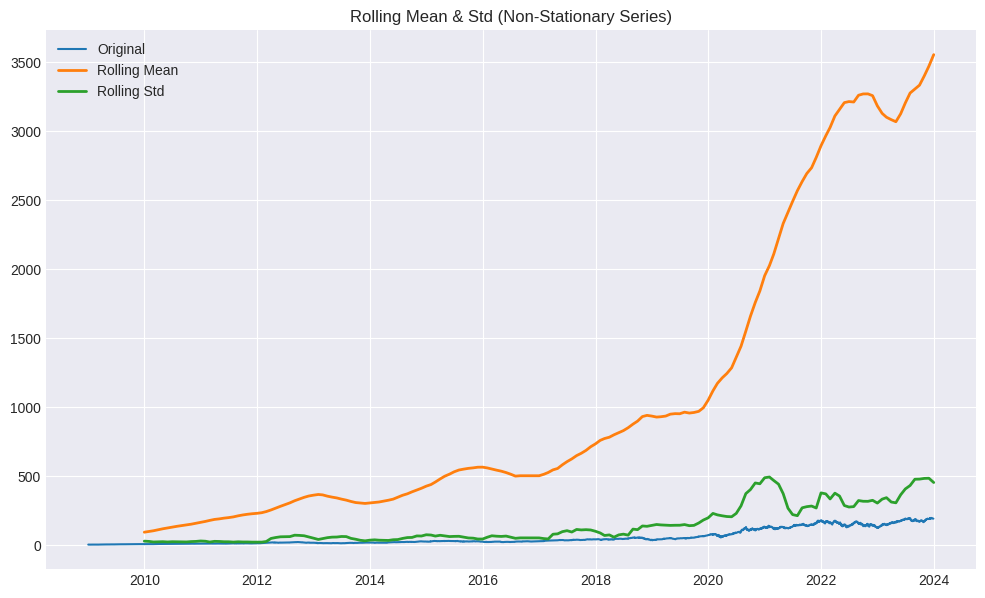

In [23]:
# Rolling statistics to check stationarity visually

window = 12  # 1 year

rolling_mean = ts["Sales"].resample('M').sum().rolling(window=window).mean()
rolling_std = ts["Sales"].resample('M').sum().rolling(window=window).std()

plt.plot(ts["Sales"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean", linewidth=2)
plt.plot(rolling_std, label="Rolling Std", linewidth=2)
plt.legend()
plt.title("Rolling Mean & Std (Non-Stationary Series)")
plt.show()

Interpretation of Rolling Mean & Standard Deviation

The plot shows the original time series alongside its rolling mean and rolling standard deviation, helping us assess stationarity:

Rolling Mean (orange) steadily increases over time, indicating a clear upward trend in the data.

Rolling Standard Deviation (green) changes over time rather than staying flat, meaning the amount of fluctuation is not constant.

Together, this confirms that the series is non-stationary, since both the average level and variability shift over the years.

In summary, the presence of a rising trend and changing variance means the data must be transformed (e.g., differenced) before applying models that require stationarity.

In [24]:
# ADF test on original series

adf_result = adfuller(ts["Sales"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: 1.0372070454941544
p-value: 0.9946434183913434


/tmp/ipykernel_8327/2638378231.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_diff = ts["Sales"].resample('M').sum().diff().dropna()


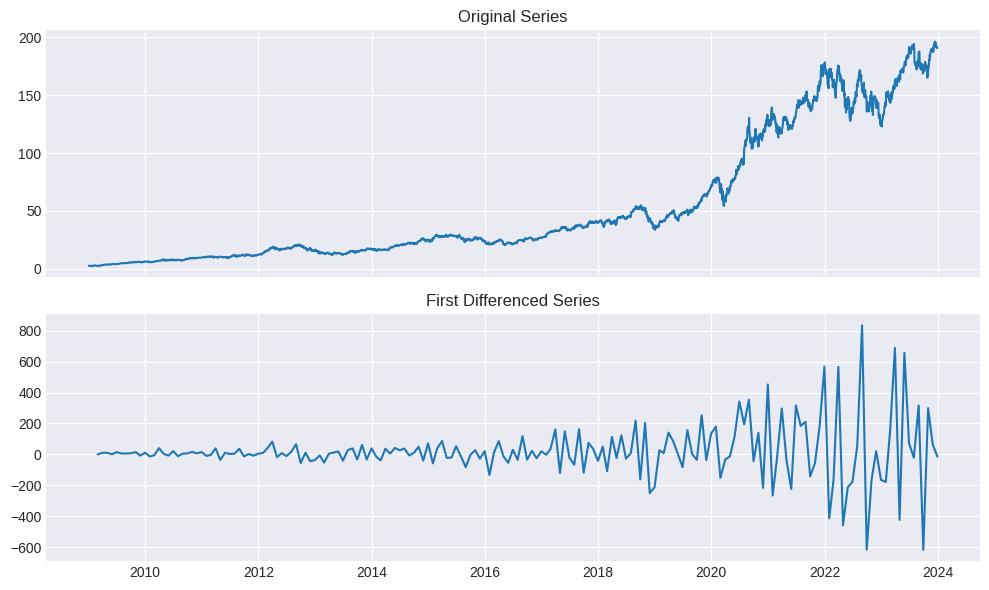

In [25]:
# First-order differencing

ts_diff = ts["Sales"].resample('M').sum().diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ts["Sales"])
axes[0].set_title("Original Series")

axes[1].plot(ts_diff)
axes[1].set_title("First Differenced Series")
plt.tight_layout()
plt.show()


Interpretation of Original vs. First Differenced Series
Original Series (Top Plot)

The original sales data shows a strong upward trend from 2018 to 2022, with clear long-term growth and changing levels over time. This indicates the series is non-stationary.

First Differenced Series (Bottom Plot)

After differencing, the trend is removed and the values now fluctuate around zero with a more stable variance. This makes the series closer to stationary, which is required for many forecasting models like ARIMA.

In [42]:
aapl_df['SMA_5'] = compute_sma(aapl_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
aapl_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,NaN
2009-01-06,2.79,NaN
2009-01-07,2.73,NaN
2009-01-08,2.78,2.77
2009-01-09,2.72,2.77
2009-01-12,2.66,2.74
2009-01-13,2.63,2.70


In [43]:
# Step 4: Calculate daily return
# Formula: (today price - yesterday price) / yesterday price * 100
aapl_df['Daily_Return'] = get_daily_return(aapl_df['Close'])

print('Daily return calculated. Positive = price went up. Negative = price went down.')
aapl_df[['Close', 'Daily_Return']].round(2).head(8)

Daily return calculated. Positive = price went up. Negative = price went down.


,Close,Daily_Return
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,4.22
2009-01-06,2.79,-1.65
2009-01-07,2.73,-2.16
2009-01-08,2.78,1.86
2009-01-09,2.72,-2.29
2009-01-12,2.66,-2.12
2009-01-13,2.63,-1.07


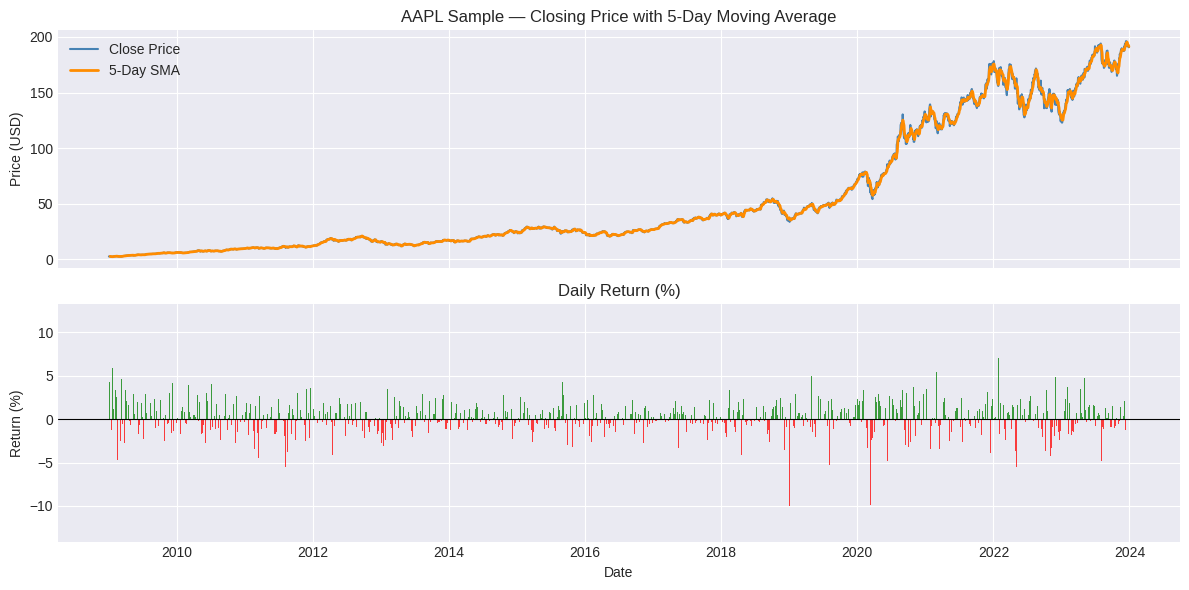

In [46]:
# Step 5: Visualise the result
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)


# Price + moving average
ax1.plot(aapl_df.index, aapl_df['Close'],  label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(aapl_df.index, aapl_df['SMA_5'],  label='5-Day SMA',   color='darkorange', linewidth=2)
ax1.set_title('AAPL Sample — Closing Price with 5-Day Moving Average')
ax1.set_ylabel('Price (USD)')
ax1.legend()

# Daily return (green = positive day, red = negative day)
colors = ['green' if r >= 0 else 'red' for r in aapl_df['Daily_Return'].fillna(0)]
ax2.bar(aapl_df.index, aapl_df['Daily_Return'], color=colors, alpha=0.75, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Daily Return (%)')
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

Pynance


In [47]:
import yfinance as yf
import talib
import pynance as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"yfinance version: {yf.__version__}")
print(f"TA-Lib version: {talib.__version__}")

yfinance version: 0.2.54
TA-Lib version: 0.6.8


###  1. SMA (Simple Moving Average) & 2. EMA (Exponential Moving Average)
Moving averages are the foundation of trend-following technical analysis.

*   **Simple Moving Average (SMA):** This is the arithmetic mean of the closing prices over a set number of periods (e.g., 20 or 50 days). It treats all days equally and is primarily used to smooth out price 'noise' and identify the long-term trend direction.
*   **Exponential Moving Average (EMA):** Unlike the SMA, the EMA gives more weight to recent prices. This makes it more responsive to new information and sudden price shifts, which is useful for identifying short-term momentum shifts.

**Interpretation:**
*   **Golden Cross:** When a short-term MA (e.g., SMA 20) crosses above a long-term MA (e.g., SMA 50), it is often seen as a bullish signal.
*   **Death Cross:** When a short-term MA crosses below a long-term MA, it is a bearish signal.

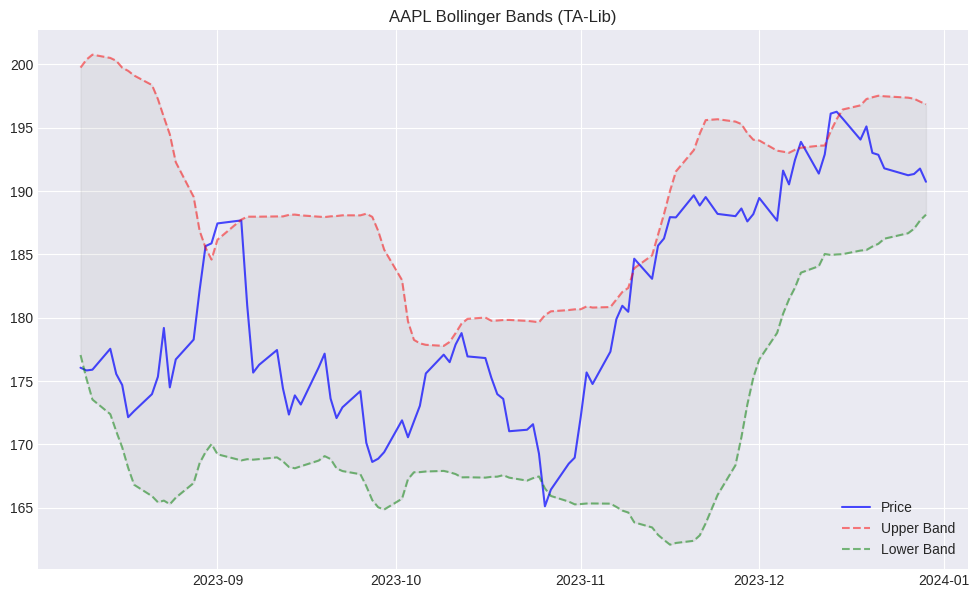

In [48]:
# Calculate Bollinger Bands
aapl_df['upper_band'], aapl_df['middle_band'], aapl_df['lower_band'] = talib.BBANDS(aapl_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

fig, ax = plt.subplots()
ax.plot(aapl_df.index[-100:], aapl_df['Close'][-100:], label='Price', color='blue', alpha=0.7)
ax.plot(aapl_df.index[-100:], aapl_df['upper_band'][-100:], label='Upper Band', color='red', linestyle='--', alpha=0.5)
ax.plot(aapl_df.index[-100:], aapl_df['lower_band'][-100:], label='Lower Band', color='green', linestyle='--', alpha=0.5)
ax.fill_between(aapl_df.index[-100:], aapl_df['lower_band'][-100:], aapl_df['upper_band'][-100:], color='gray', alpha=0.1)

ax.set_title(f"AAPL Bollinger Bands (TA-Lib)")
ax.legend()
plt.show()

###  3. RSI (Relative Strength Index)
The RSI is a **momentum oscillator** that measures the speed and change of price movements. It oscillates between 0 and 100.

*   **Overbought (>= 70):** Suggests that the asset may be overvalued and could be due for a price correction or a reversal.
*   **Oversold (<= 30):** Suggests that the asset may be undervalued and could be due for a bounce or an upward trend reversal.
*   **Centerline (50):** A crossover of the 50 level often indicates a shift in the overall trend direction (bullish above, bearish below).

###  4. MACD (Moving Average Convergence Divergence)
The MACD is a trend-following momentum indicator that shows the relationship between two moving averages of an assetâ€™s price.

*   **MACD Line:** The difference between the 12-day EMA and 26-day EMA.
*   **Signal Line:** A 9-day EMA of the MACD Line.
*   **Histogram:** The visual difference between the MACD Line and the Signal Line.

**How to Read:**
*   **Bullish Crossover:** When the MACD line crosses above the Signal line.
*   **Bearish Crossover:** When the MACD line crosses below the Signal line.
*   **Divergence:** When the price makes a new high but the MACD histogram does not, suggesting the trend is weakening.

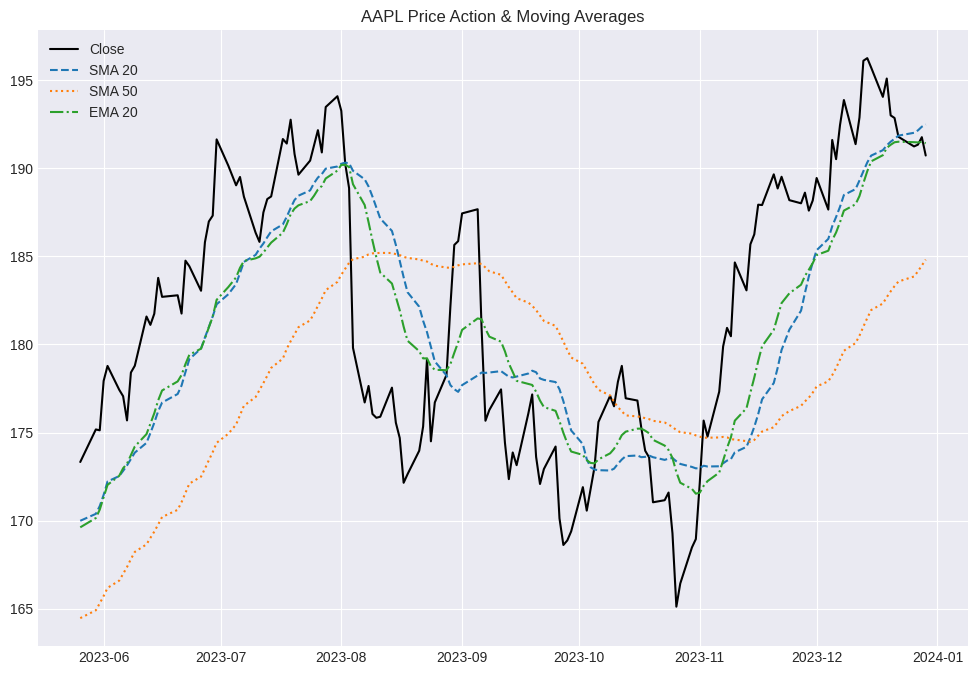

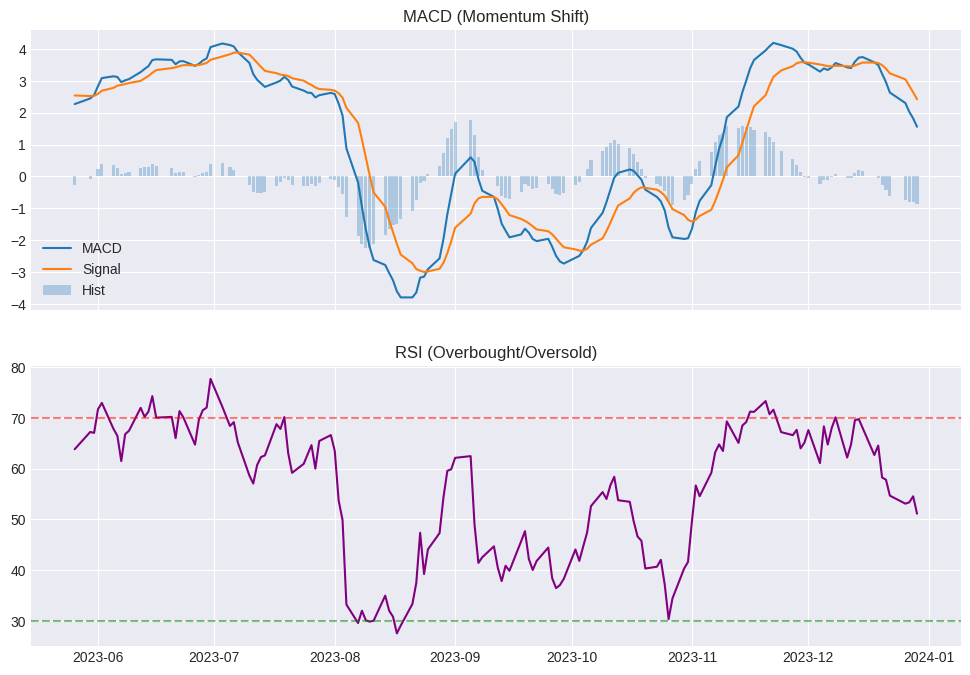

In [50]:
# Calculate Multiple Moving Averages
aapl_df['SMA_20'] = talib.SMA(aapl_df['Close'], timeperiod=20)
aapl_df['SMA_50'] = talib.SMA(aapl_df['Close'], timeperiod=50)
aapl_df['EMA_20'] = talib.EMA(aapl_df['Close'], timeperiod=20)

# Calculate Bollinger Bands
aapl_df['upper_band'], aapl_df['middle_band'], aapl_df['lower_band'] = talib.BBANDS(aapl_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

# RSI & MACD
aapl_df['RSI'] = talib.RSI(aapl_df['Close'], timeperiod=14)
aapl_df['macd'], aapl_df['macdsignal'], aapl_df['macdhist'] = talib.MACD(aapl_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
# --- VISUALIZATION: Prices overlaid with MAs ---
plt.figure(figsize=(12, 8))
plt.plot(aapl_df.index[-150:], aapl_df['Close'][-150:], label='Close', color='black', linewidth=1.5)
plt.plot(aapl_df.index[-150:], aapl_df['SMA_20'][-150:], label='SMA 20', linestyle='--')
plt.plot(aapl_df.index[-150:], aapl_df['SMA_50'][-150:], label='SMA 50', linestyle=':')
plt.plot(aapl_df.index[-150:], aapl_df['EMA_20'][-150:], label='EMA 20', linestyle='-.')
plt.title(f"AAPL Price Action & Moving Averages")
plt.legend()
plt.show()

# --- VISUALIZATION: RSI and MACD in separate panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
# MACD
ax1.plot(aapl_df.index[-150:], aapl_df['macd'][-150:], label='MACD')
ax1.plot(aapl_df.index[-150:], aapl_df['macdsignal'][-150:], label='Signal')
ax1.bar(aapl_df.index[-150:], aapl_df['macdhist'][-150:], label='Hist', alpha=0.3)
ax1.set_title("MACD (Momentum Shift)")
ax1.legend()

# RSI
ax2.plot(aapl_df.index[-150:], aapl_df['RSI'][-150:], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title("RSI (Overbought/Oversold)")
plt.show()

### 5. Quantitative Analysis & Backtesting
We calculate returns and simulate a simple crossover strategy.

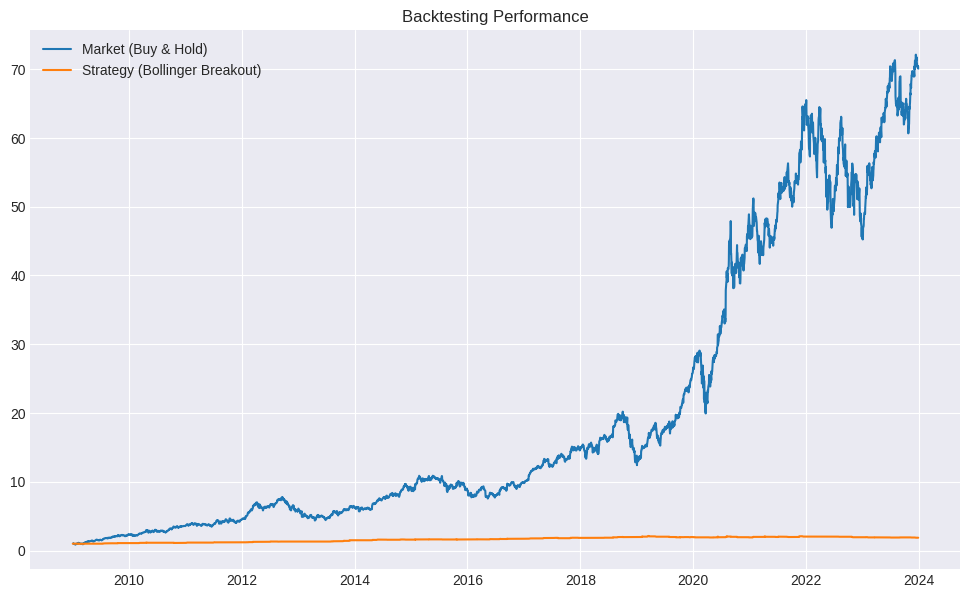

In [51]:
aapl_df['Returns'] = aapl_df['Close'].pct_change()

# Simple Strategy: Buy when Close > Upper Band (Breakout)
aapl_df['Signal'] = 0
aapl_df.loc[aapl_df['Close'] > aapl_df['upper_band'], 'Signal'] = 1
aapl_df['Strategy_Returns'] = aapl_df['Signal'].shift(1) * aapl_df['Returns']

cumulative_market = (1 + aapl_df['Returns']).cumprod()
cumulative_strategy = (1 + aapl_df['Strategy_Returns'].fillna(0)).cumprod()

plt.plot(cumulative_market, label='Market (Buy & Hold)')
plt.plot(cumulative_strategy, label='Strategy (Bollinger Breakout)')
plt.title("Backtesting Performance")
plt.legend()
plt.show()